# Data Project: "Podiumkunsten NL, voorstellingen, bezoekers"
Data is gathered from **cbsodata platform**; **"cbs.nl"**. 

This project was developed during my Data Engineering studies at Bit Academy. As a classical pianist (MMus), I built this data visualization pipeline to analyze socio-economic datasets from CBS, preparing visual insights for my academic research and future publications.

This presentation compares **"Art Performance Sector"** with subcategories of __"Performances" and "Visitors"__ in different regions of NL.

Focus theme: __"Music"__.

In [1]:
import cbsodata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import random
from pprint import pprint
tables = cbsodata.get_table_list()
list_dict = tables[0]
list_dict.keys()
for table in tables:
    if 'podiumkunsten' in table['Title']:
        print(table['Identifier'], table['Title'])

ModuleNotFoundError: No module named 'cbsodata'

### Gathering all the data for our main category: 'Art Performance Sector'.

In [ ]:
for table in tables:
    if table['Identifier'] == '70077NED':
        print(table['Title'], table['Identifier'])
info = cbsodata.get_info('70077NED')

Professionele podiumkunsten; capaciteit, voorstellingen, bezoekers, regio 70077NED


### Focus theme: 'music' .

In [ ]:
data = pd.DataFrame(cbsodata.get_data('70077NED'))
data.rename(columns={"Perioden": "Years", "RegioS": "Regions", "TotaalVoorstellingen_6": "AllPerformances", "Muziekvoorstellingen_8": "MusicPerformances", "TotaalBezoekenAanVoorstellingen_13": "TotalVisitors", "Muziekvoorstellingen_15": "MusicPerformanceVisitors"},  inplace=True)
df = data.set_index('Years')
df2 =  df.drop_duplicates(subset=['ID'])
df2.drop(columns=['ID'], inplace=True)
df_refined = df2.iloc[:,[0,6,8,13,15]]

**Mix chart:** We can see all the data plotted below; but do we need all? Or does it **confuse** us..

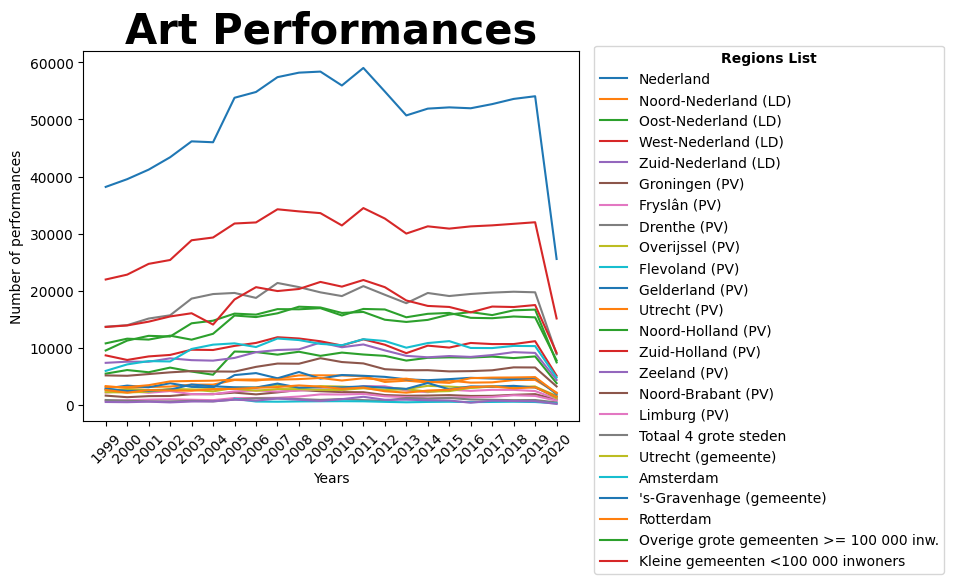

In [ ]:
for i in df_refined['Regions'].unique():
    mix_regions = df_refined[df_refined['Regions']==i]
    plt.xticks(rotation=45)
    plt.plot(mix_regions.index, mix_regions['AllPerformances'], label=i)
    plt.legend(loc="right", title='Regions List', title_fontproperties={'weight':'bold'}, bbox_to_anchor=(1.75, 0.3))
    # confusing chart since it includes all regions
plt.title("Art Performances", loc='center', fontsize=30, rotation=0, weight='bold');
plt.xlabel("Years")
plt.ylabel("Number of performances");

### Sub categories:  "Performances" and "Visitors"
**NL chart**: It is easier to see meaningul information on this chart below related to the sub categories.

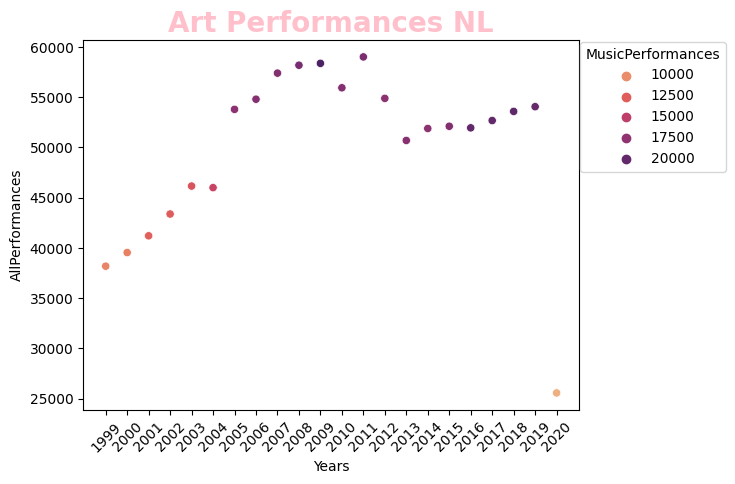

In [ ]:
nl = df_refined[df_refined['Regions']==df_refined['Regions'].unique()[0]]
plt.xticks(rotation=45)
sns.color_palette("flare")
sns.scatterplot(x=nl.index, y='AllPerformances',  hue='MusicPerformances', palette='flare', data=nl);
plt.legend(loc="right", title="MusicPerformances", bbox_to_anchor=(1.31, 0.82));
plt.title("Art Performances NL", loc='center', color='pink', fontsize=20,rotation=0, weight='bold');

Filtering multiple values for column. Nice to see **"Performances" and "Visitors"** data of NL per region.

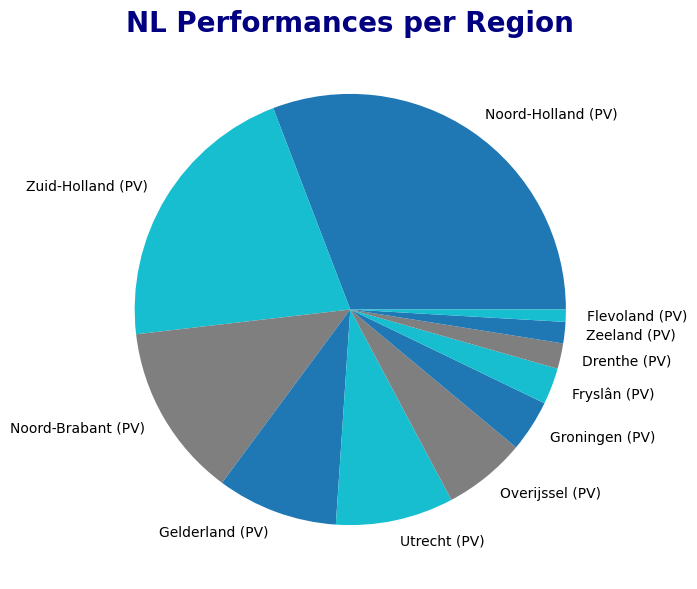

In [ ]:
nl_regions_list = df_refined['Regions'].unique()[5:16]
regions_combi = df_refined[df_refined['Regions'].isin(nl_regions_list)]
pie_region = regions_combi.groupby(['Regions'])[['AllPerformances','MusicPerformances']].sum();
pie_region_sorted_allP = pie_region['AllPerformances'].sort_values(ascending=False)
colors = ['tab:blue', 'tab:cyan', 'tab:gray']
pie_region_sorted_allP.plot.pie(y='Regions', label="", title='Art Performances', colors=colors, figsize=(7,7));
plt.title("NL Performances per Region", loc='center', color='navy', fontsize=20,rotation=0, weight='bold');

The **box plot** lets us see 'the numbers', instead of 'the division on regions'. The numbers are important. We can see in an instant that **'North Holland"** reaches 15k and low values align below 5k. This was not clear on a **pie plot** above.

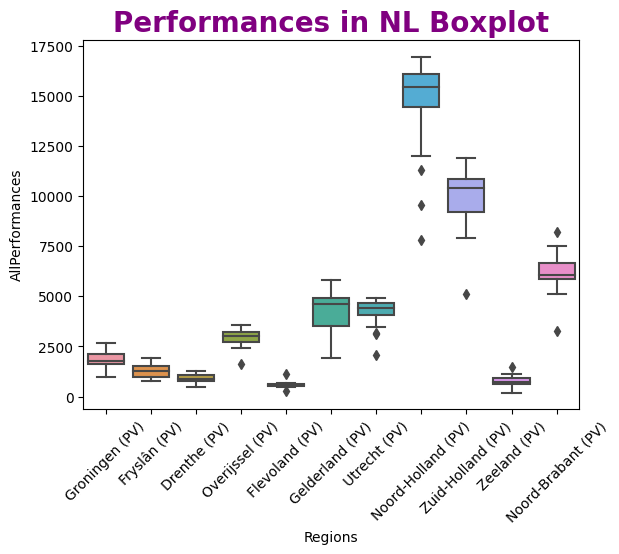

In [ ]:
ax = sns.boxplot(x='Regions', y='AllPerformances', data=regions_combi);
ax.tick_params(axis='x', labelrotation=45)
plt.title("Performances in NL Boxplot", loc='center', color='purple', fontsize=20,rotation=0, weight='bold');

##### Below we see the data on a new perspective of divisions. If you do not know the cities of 'west NL', this data does not tell much..

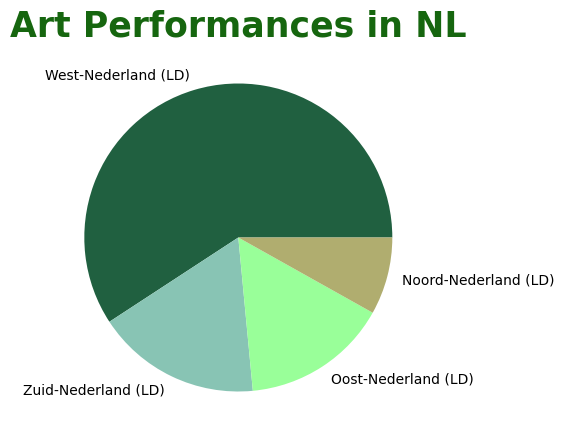

In [ ]:
nl_4_division_list = df_refined['Regions'].unique()[1:5]
nl_4 = df_refined[df_refined['Regions'].isin(nl_4_division_list)]
pie_nl_4 = nl_4.groupby(['Regions'])[['AllPerformances','MusicPerformances']].sum();
pie_nl_4_sorted_allP = pie_nl_4['AllPerformances'].sort_values(ascending=False)
colors = ['#206040','#88C4B4','#99ff99','#B0AD6F']
pie_nl_4_sorted_allP.plot.pie(y='Regions', label="", title='Art Performances', colors=colors, figsize=(5,5));
plt.title("Art Performances in NL", loc='center', color='#16660F', fontsize=25, rotation=0, weight='bold');


This is an important pie! **The 4 big cities of The Netherlands; Amsterdam, Utrecht, Den Haag and Rotterdam**, hold together a big portion of the pie. **How big?**; well as big as the rest of the big cities or all the other small cities!!

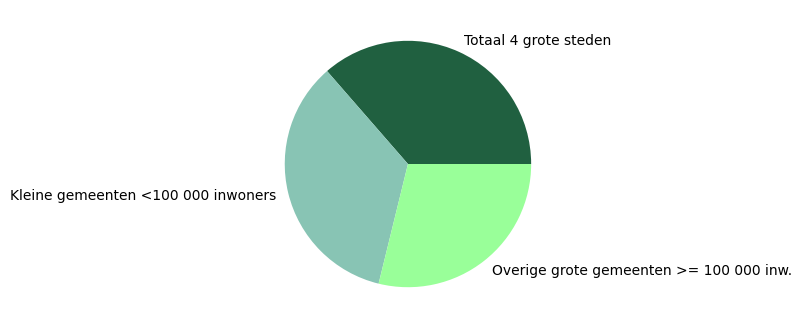

In [ ]:
four_big_cities = df_refined[df_refined['Regions']==df_refined['Regions'].unique()[17]]
other_big_cities = df_refined[df_refined['Regions']==df_refined['Regions'].unique()[22]]
small_cities = df_refined[df_refined['Regions']==df_refined['Regions'].unique()[23]]
nl_devided = [four_big_cities, other_big_cities, small_cities]
comb_three = pd.concat(nl_devided)
df3 = comb_three.groupby(['Regions'])[['AllPerformances', 'MusicPerformances']].sum();
df3_sorted = df3['AllPerformances'].sort_values(ascending=False)
colors = ['#206040','#88C4B4','#99ff99','#B0AD6F']
df3_sorted.plot.pie(y='Regions', label="", colors=colors, figsize=(4, 4));

Do **'Music Performances'** hold a big percentage of events when **all the other** performances are taken into the consideration? **The answer is: below, Just look at the chart!!**

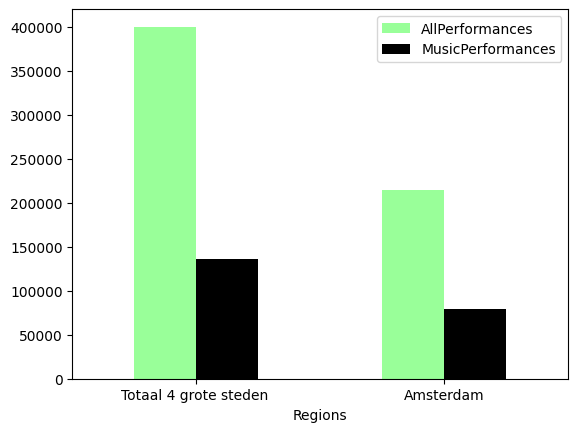

In [ ]:
ams = df_refined[df_refined['Regions']==df_refined['Regions'].unique()[19]]
ams_total = ams.groupby(['Regions'])[['AllPerformances', 'MusicPerformances']].sum();
ams_total_sorted_all = ams_total['AllPerformances'].sort_values(ascending=False)
df4 = four_big_cities.groupby(['Regions'])[['AllPerformances', 'MusicPerformances']].sum();
df4_sorted_all = df4['AllPerformances'].sort_values(ascending=False)

proportion_Ams = [df4, ams_total]
comparison = pd.concat(proportion_Ams)
colors = ['#99ff99','black']
comparison.plot(kind='bar', color=colors)
plt.xticks(rotation=0);


We have seen with the chart above that the maximum number of 'all performances' hit almost 60k. And here is the **exact number** value:

In [ ]:
nl['AllPerformances'].max()

59004.0

It is time to compare **"All Performances"** to **"Music Performances"** in NL as well as the **"Total Visitors"** of these events and **"Music Performance Visitors"**. 

**The charts speak more than words!!**

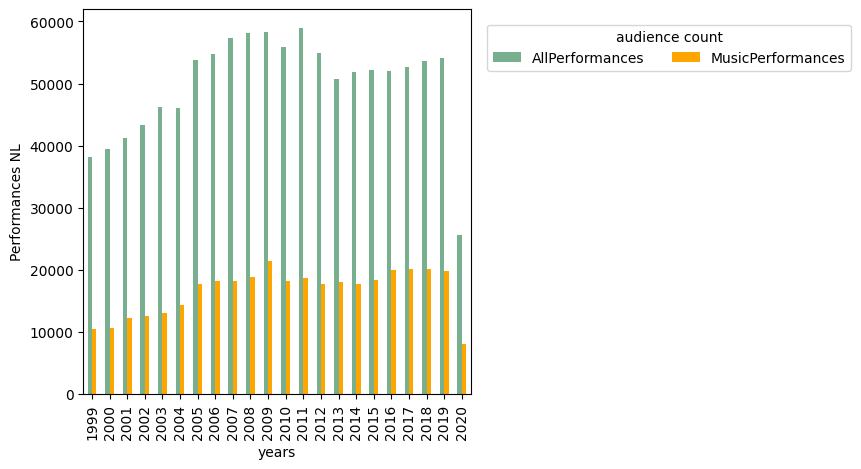

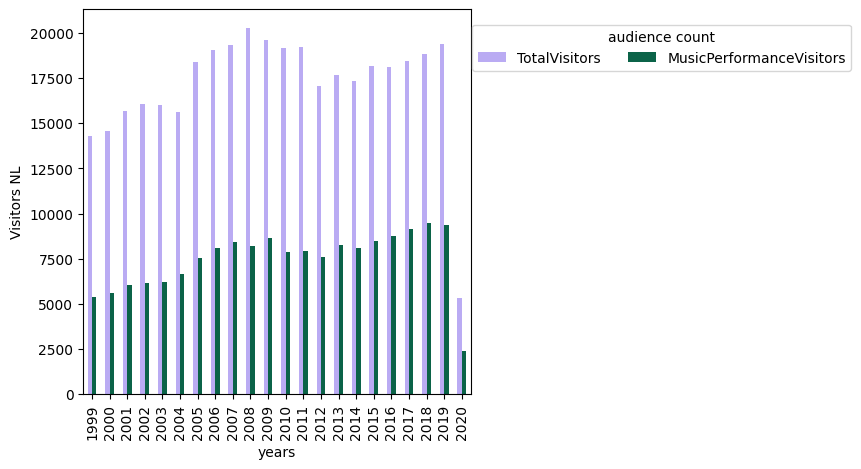

In [ ]:
Performances = nl.iloc[:,[0,1,2]]
Visitors= nl.iloc[:,[0,3,4]]
Performances.plot(kind='bar', title='', ylabel='Performances NL', xlabel='years', 
                  color=['#78AF8E','orange'], figsize=(5, 5))
plt.legend(loc="center right", ncol = 3, title='audience count', bbox_to_anchor=(2, 0.9))
Performances.plot;
Visitors.plot(kind='bar', title='', ylabel='Visitors NL', xlabel='years', 
              color=['#BAABF3','#0B6348'], figsize=(5, 5))
plt.legend(loc="center right", ncol = 3, title='audience count', bbox_to_anchor=(2, 0.9))
Visitors.plot;


### The 'overview':

The overview figure is letting us reconsider **'Years'** of the recorded data...

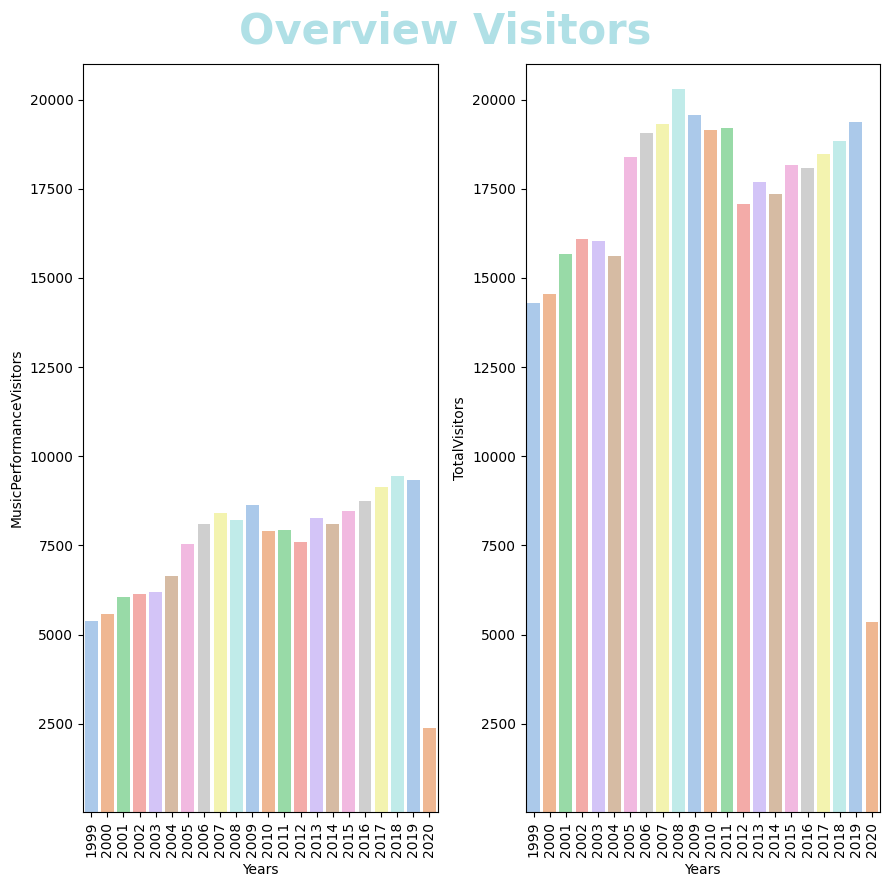

In [ ]:
z = nl.groupby('Years')['TotalVisitors'].mean()
z.keys()
w = nl.groupby('Years')['MusicPerformanceVisitors'].mean()
w.keys()
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 9))

plt.xticks(rotation=90)
sns.barplot(x=w.keys(), y=w, palette="pastel", ax=ax1)
ax1.tick_params(axis='x', labelrotation=90)
ax1.set_ylim(21, 21000)
sns.barplot(x=z.keys(), y=z, palette="pastel", ax=ax2)
ax2.set_ylim(21, 21000)
fig.suptitle('Overview Visitors', fontsize=30, weight='bold', color='powderblue');
fig.tight_layout()

## Just before the conclusion, a few more lines of observations;

Merging the average numbers of all categories below, we can see the relation between them, on a single lign. 

In [ ]:
average_allP = nl.groupby(['Regions'])[['AllPerformances']].mean();
average_Mus = nl.groupby(['Regions'])[['MusicPerformances']].mean();
av_P = pd.merge(average_allP, average_Mus, on='Regions')
average_vis = nl.groupby(['Regions'])[['TotalVisitors']].mean();
average_musVis = nl.groupby(['Regions'])[['MusicPerformanceVisitors']].mean();
av_V = pd.merge(average_vis, average_musVis, on='Regions')
df_av = pd.merge(av_P, av_V, on='Regions')
df_av

,AllPerformances,MusicPerformances,TotalVisitors,MusicPerformanceVisitors
Regions,,,,
Nederland,49967.681818,16589.181818,17165.136364,7463.181818


We can drop the year '2020' and see it will not effect the average considerably.

In [ ]:
drop_index = nl.drop('2020')
d = drop_index
d_P = d.groupby(['Regions'])[['AllPerformances']].mean();
d_Mus = d.groupby(['Regions'])[['MusicPerformances']].mean();
dv_P = pd.merge(d_P, d_Mus, on='Regions')
dvis = d.groupby(['Regions'])[['TotalVisitors']].mean();
dmusVis = d.groupby(['Regions'])[['MusicPerformanceVisitors']].mean();
dv_V = pd.merge(dvis, dmusVis, on='Regions')
dv_av = pd.merge(dv_P, dv_V, on='Regions')
dv_av

,AllPerformances,MusicPerformances,TotalVisitors,MusicPerformanceVisitors
Regions,,,,
Nederland,51129.428571,16993.238095,17727.761905,7705.190476


We could even get the top 5 years for audiance attendance..

In [ ]:
d['percentageV'] = d['MusicPerformanceVisitors'] / d['TotalVisitors'] * 100
d_sorted = d['percentageV'].sort_values(ascending=False)
top5years = d_sorted[:5]
top5years

Years
2018    50.196307
2017    49.485541
2016    48.379962
2019    48.237783
2013    46.689285
Name: percentageV, dtype: float64

Or, we could even get the top 5 years for activity productivity in the sector.

In [ ]:
d['percentageP'] = d['MusicPerformances'] / d['AllPerformances'] * 100
d_sorted = d['percentageP'].sort_values(ascending=False)
top5years = d_sorted[:5]
top5years

Years
2016    38.633607
2017    38.103465
2018    37.732117
2019    36.697995
2009    36.664725
Name: percentageP, dtype: float64

## Conclusion:
We can see the exact percentage of "Music Performances" on the data collection of "All Performances" between the years 1999-2019.

In [ ]:
d['percentageV'].mean()

43.27397514346977

We can see the exact percentage of "Music Performance Visitors"(attendacy of audiance) on the data collection of "All Performance Visitors", between the years 1999-2019.

_Please note that all of "the visitor counts" are in fact to be multiplied by "x1000" as it was stated on cbsodata platform. You can check that with #pprint(info) while gathering the initial data or its tables._


In [ ]:
d['percentageP'].mean()


32.979254730163724

It still makes it more presentable to put facts on a graph. Please see the percentage of Music Performance Visitors below.

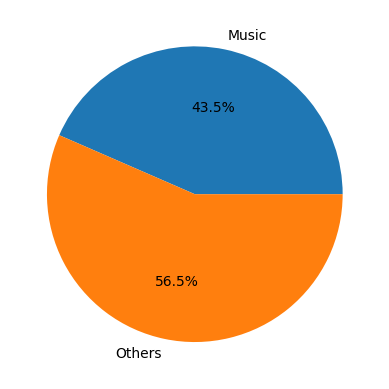

In [ ]:
plt.pie([d['MusicPerformanceVisitors'].mean(),
        (d['TotalVisitors']-d['MusicPerformanceVisitors']).mean()], 
        labels=['Music', 'Others'], autopct='%.1f%%');

It still makes it more presentable to put facts on a graph. Please see the percentage of Music Performances below.

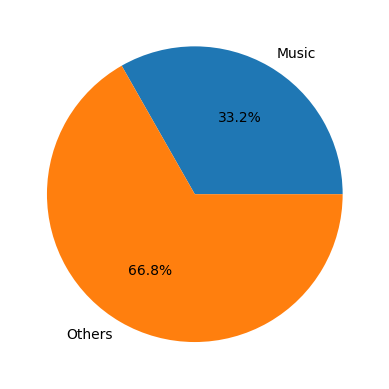

In [ ]:
plt.pie([d['MusicPerformances'].mean(),
        (d['AllPerformances']-d['MusicPerformances']).mean()], labels=['Music', 'Others'], autopct='%.1f%%');

Thank you and I hope you have some insight now how "music" is preferred in art and how "cities" like Amsterdam holds the "heart beat" of cultural activities. 
**Keep attending to musical events wherever you are, it is good for your soul and many people know it, even cbs platform knows it and now BIT Academy Data Reviewer/Coach knows it, with facts!!**

Cheers, Selen Apaydin